In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%cd /content/drive/MyDrive/src


/content/drive/MyDrive/src


In [3]:
!pip install munch
# should change import imp to import importlib

In [4]:
from collections import OrderedDict
import re
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from tqdm.notebook import tqdm

from eval import get_run_metrics, read_run_dir, get_model_from_run
from plot_utils import basic_plot, collect_results, relevant_model_names

%matplotlib inline
%load_ext autoreload
%autoreload 2

sns.set_theme('notebook', 'darkgrid')
palette = sns.color_palette('colorblind')

run_dir = "../models"

In [5]:
#%cd /content/drive/MyDrive/models/polynomial_regression/baseline/
%cd /content/drive/MyDrive/models/polynomial_regression/moe/
import torch

#convert checkpoint to .pt file
checkpoint_path = "checkpoint_3000000"
output_path = "model_0.pt"
out_put_dir="./"

ckpt = torch.load(checkpoint_path, map_location="cpu")

state_dict = ckpt["model_state_dict"]

torch.save(state_dict, output_path)

print("Exported state.pt successfully!")

#_ = get_run_metrics(out_put_dir,step=0) #rerun the evaluation

%cd /content/drive/MyDrive/src

/content/drive/MyDrive/models/polynomial_regression/moe
Exported state.pt successfully!
Munch({'model': Munch({'family': 'gpt2_var_moe', 'vocab_size': 1, 'glu_type': 'None', 'n_dims': 1, 'n_embd': 128, 'n_head': 4, 'n_layer': 6, 'n_positions': 81, 'top_k': 1, 'num_experts': 4}), 'out_dir': '../models/polynomial_regression/moe', 'test_run': True, 'training': Munch({'batch_size': 64, 'curriculum': Munch({'degree': Munch({'end': 11, 'inc': 2, 'interval': 2000, 'start': 1}), 'points': Munch({'end': 81, 'inc': 2, 'interval': 2000, 'start': 5})}), 'data': 'uniform', 'keep_every_steps': 100000, 'learning_rate': 0.0001, 'num_tasks': None, 'num_training_examples': None, 'resume_id': None, 'save_every_steps': 1000, 'task': 'polynomial_regression', 'task_kwargs': Munch({}), 'train_steps': 3002000}), 'wandb': Munch({'entity': 'quzhaorui22-university-of-chinese-of-academy-of-sciences', 'log_every_steps': 100, 'name': 'polynomial_regression_toy', 'notes': '', 'project': 'in-context-training'})})


  0%|          | 0/8 [00:00<?, ?it/s]

{}
in evaluate poly_family: chebyshev
in evaluate degree: 11
in evaluate noise: False
in evaluate noise_std: 0
in evaluate poly_family: chebyshev
in evaluate degree: 11
in evaluate noise: False
in evaluate noise_std: 0
in evaluate poly_family: chebyshev
in evaluate degree: 11
in evaluate noise: False
in evaluate noise_std: 0
in evaluate poly_family: chebyshev
in evaluate degree: 11
in evaluate noise: False
in evaluate noise_std: 0
in evaluate poly_family: chebyshev
in evaluate degree: 11
in evaluate noise: False
in evaluate noise_std: 0
in evaluate poly_family: chebyshev
in evaluate degree: 11
in evaluate noise: False
in evaluate noise_std: 0
in evaluate poly_family: chebyshev
in evaluate degree: 11
in evaluate noise: False
in evaluate noise_std: 0
in evaluate poly_family: chebyshev
in evaluate degree: 11
in evaluate noise: False
in evaluate noise_std: 0
in evaluate poly_family: chebyshev
in evaluate degree: 11
in evaluate noise: False
in evaluate noise_std: 0
in evaluate poly_family: 

 12%|█▎        | 1/8 [01:37<11:20, 97.24s/it]

{'max_degree': 12, 'noise': False}
in evaluate poly_family: chebyshev
in evaluate degree: 12
in evaluate noise: False
in evaluate noise_std: 0
in evaluate poly_family: chebyshev
in evaluate degree: 12
in evaluate noise: False
in evaluate noise_std: 0
in evaluate poly_family: chebyshev
in evaluate degree: 12
in evaluate noise: False
in evaluate noise_std: 0
in evaluate poly_family: chebyshev
in evaluate degree: 12
in evaluate noise: False
in evaluate noise_std: 0
in evaluate poly_family: chebyshev
in evaluate degree: 12
in evaluate noise: False
in evaluate noise_std: 0
in evaluate poly_family: chebyshev
in evaluate degree: 12
in evaluate noise: False
in evaluate noise_std: 0
in evaluate poly_family: chebyshev
in evaluate degree: 12
in evaluate noise: False
in evaluate noise_std: 0
in evaluate poly_family: chebyshev
in evaluate degree: 12
in evaluate noise: False
in evaluate noise_std: 0
in evaluate poly_family: chebyshev
in evaluate degree: 12
in evaluate noise: False
in evaluate noise_

...

{'noise': True, 'noise_std': 0.1}
in evaluate poly_family: chebyshev
in evaluate degree: 11
in evaluate noise: True
in evaluate noise_std: 0.1
in evaluate poly_family: chebyshev
in evaluate degree: 11
in evaluate noise: True
in evaluate noise_std: 0.1
in evaluate poly_family: chebyshev
in evaluate degree: 11
in evaluate noise: True
in evaluate noise_std: 0.1
in evaluate poly_family: chebyshev
in evaluate degree: 11
in evaluate noise: True
in evaluate noise_std: 0.1
in evaluate poly_family: chebyshev
in evaluate degree: 11
in evaluate noise: True
in evaluate noise_std: 0.1
in evaluate poly_family: chebyshev
in evaluate degree: 11
in evaluate noise: True
in evaluate noise_std: 0.1
in evaluate poly_family: chebyshev
in evaluate degree: 11
in evaluate noise: True
in evaluate noise_std: 0.1
in evaluate poly_family: chebyshev
in evaluate degree: 11
in evaluate noise: True
in evaluate noise_std: 0.1
in evaluate poly_family: chebyshev
in evaluate degree: 11
in evaluate noise: True
in evaluate 

 88%|████████▊ | 7/8 [11:04<01:35, 95.44s/it]

{'poly_family': 'monomial', 'noise': True, 'noise_std': 0.1}
in evaluate poly_family: monomial
in evaluate degree: 11
in evaluate noise: True
in evaluate noise_std: 0.1
in evaluate poly_family: monomial
in evaluate degree: 11
in evaluate noise: True
in evaluate noise_std: 0.1
in evaluate poly_family: monomial
in evaluate degree: 11
in evaluate noise: True
in evaluate noise_std: 0.1
in evaluate poly_family: monomial
in evaluate degree: 11
in evaluate noise: True
in evaluate noise_std: 0.1
in evaluate poly_family: monomial
in evaluate degree: 11
in evaluate noise: True
in evaluate noise_std: 0.1
in evaluate poly_family: monomial
in evaluate degree: 11
in evaluate noise: True
in evaluate noise_std: 0.1
in evaluate poly_family: monomial
in evaluate degree: 11
in evaluate noise: True
in evaluate noise_std: 0.1
in evaluate poly_family: monomial
in evaluate degree: 11
in evaluate noise: True
in evaluate noise_std: 0.1
in evaluate poly_family: monomial
in evaluate degree: 11
in evaluate noise:

100%|██████████| 8/8 [12:39<00:00, 94.98s/it]

/content/drive/MyDrive/src


In [6]:
%cd /content/drive/MyDrive/src
df = read_run_dir(run_dir)
df  # list all the runs in our run_dir

/content/drive/MyDrive/src
baseline
moe


,run_id,task,model,kwargs,num_tasks,num_examples,n_dims,n_layer,n_head,run_name
0,baseline,polynomial_regression,Transformer-small,,-1,-1,1,6,4,polynomial_regression/baseline
1,moe,polynomial_regression,polynomial_regression_toy,,-1,-1,1,6,4,polynomial_regression/moe


In [7]:

task = "polynomial_regression"

#run_id = "baseline"
run_id = "moe"


run_path = os.path.join(run_dir, task, run_id)

# Plot pre-computed metrics

polynomial_regression/moe moe
Munch({'model': Munch({'family': 'gpt2_var_moe', 'vocab_size': 1, 'glu_type': 'None', 'n_dims': 1, 'n_embd': 128, 'n_head': 4, 'n_layer': 6, 'n_positions': 81, 'top_k': 1, 'num_experts': 4}), 'out_dir': '../models/polynomial_regression/moe', 'test_run': True, 'training': Munch({'batch_size': 64, 'curriculum': Munch({'degree': Munch({'end': 11, 'inc': 2, 'interval': 2000, 'start': 1}), 'points': Munch({'end': 81, 'inc': 2, 'interval': 2000, 'start': 5})}), 'data': 'uniform', 'keep_every_steps': 100000, 'learning_rate': 0.0001, 'num_tasks': None, 'num_training_examples': None, 'resume_id': None, 'save_every_steps': 1000, 'task': 'polynomial_regression', 'task_kwargs': Munch({}), 'train_steps': 3002000}), 'wandb': Munch({'entity': 'quzhaorui22-university-of-chinese-of-academy-of-sciences', 'log_every_steps': 100, 'name': 'polynomial_regression_toy', 'notes': '', 'project': 'in-context-training'})})


100%|██████████| 8/8 [00:00<00:00, 79324.90it/s]

gpt2_moe_embd=128_layer=6_head=4_experts=4
in gpt2: Transformer
OLS_driver=None
ChebyshevFitModel
NN_n=3_uniform
decision_tree_max_depth=4
gpt2_moe_embd=128_layer=6_head=4_experts=4
in gpt2: Transformer
OLS_driver=None
ChebyshevFitModel
NN_n=3_uniform
decision_tree_max_depth=4
gpt2_moe_embd=128_layer=6_head=4_experts=4
in gpt2: Transformer
OLS_driver=None
ChebyshevFitModel
NN_n=3_uniform
decision_tree_max_depth=4
gpt2_moe_embd=128_layer=6_head=4_experts=4
in gpt2: Transformer
OLS_driver=None
ChebyshevFitModel
NN_n=3_uniform
decision_tree_max_depth=4
gpt2_moe_embd=128_layer=6_head=4_experts=4
in gpt2: Transformer
OLS_driver=None
ChebyshevFitModel
NN_n=3_uniform
decision_tree_max_depth=4
gpt2_moe_embd=128_layer=6_head=4_experts=4
in gpt2: Transformer
OLS_driver=None
ChebyshevFitModel
NN_n=3_uniform
decision_tree_max_depth=4
gpt2_moe_embd=128_layer=6_head=4_experts=4
in gpt2: Transformer
OLS_driver=None
ChebyshevFitModel
NN_n=3_uniform
decision_tree_max_depth=4
gpt2_moe_embd=128_layer=6_h

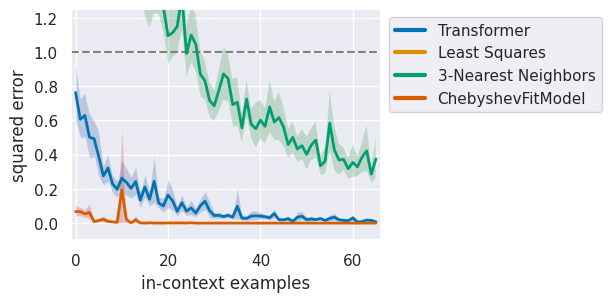

In [8]:
def valid_row(r):
    return r.task == task and r.run_id == run_id

metrics = collect_results(run_dir, df, valid_row=valid_row)
_, conf = get_model_from_run(run_path, only_conf=True)
n_dims = conf.model.n_dims

models = relevant_model_names[task]
print(metrics)
basic_plot(metrics["standard"], models=models)
plt.show()
#baseline model may be wrong(need further investigation)

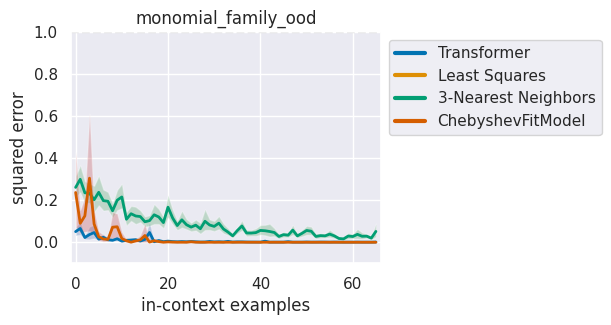

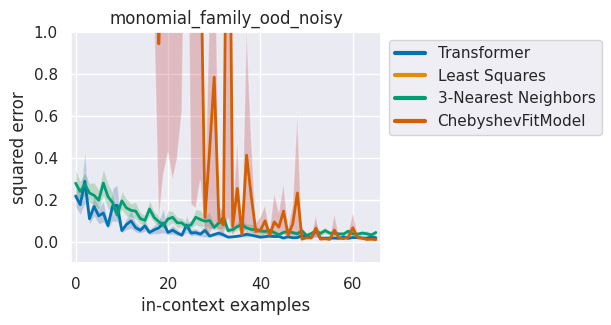

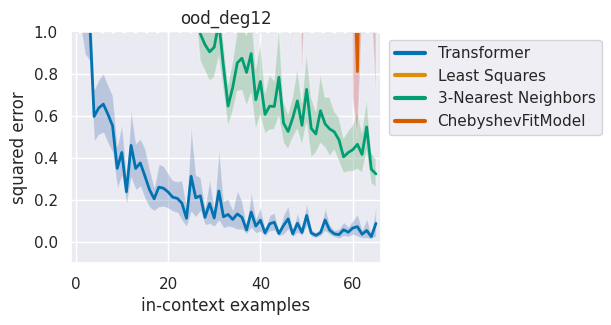

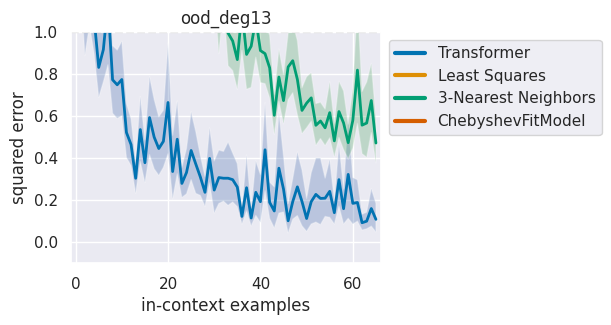

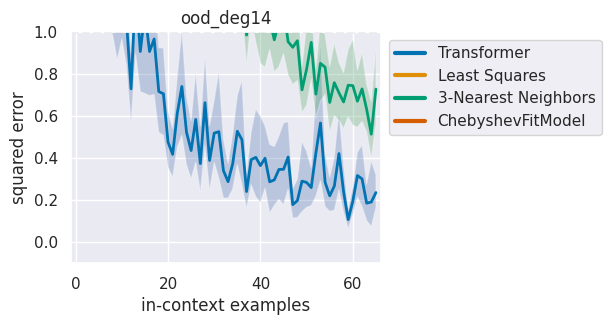

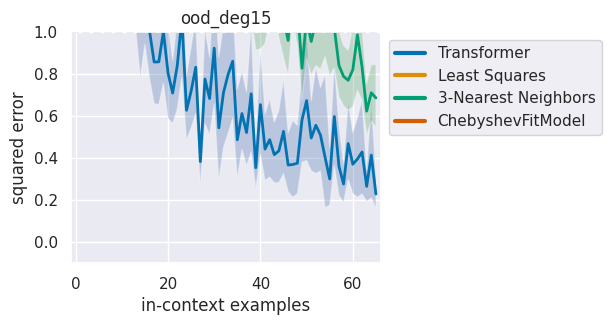

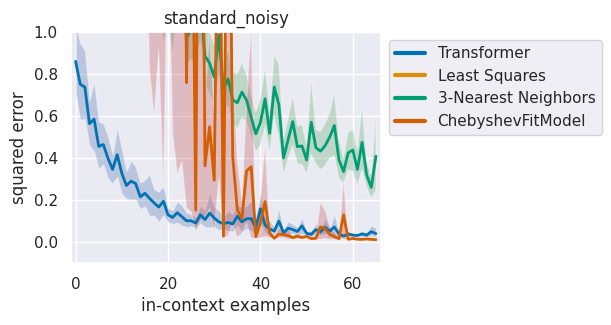

In [9]:
# plot any OOD metrics
for name, metric in metrics.items():
    if name == "standard": continue

    if "scale" in name:
        scale = float(name.split("=")[-1])**2
    else:
        scale = 1.0

    trivial = 1.0 if "noisy" not in name else (1+1/n_dims)
    fig, ax = basic_plot(metric, models=models, trivial=trivial * scale)
    ax.set_title(name)

    if "ortho" in name:
        ax.set_xlim(-1, n_dims - 1)
    ax.set_ylim(-0.1* scale, 1 * scale)

    plt.show()

# Interactive setup

We will now directly load the model and measure its in-context learning ability on a batch of random inputs. (In the paper we average over multiple such batches to obtain better estimates.)

In [10]:
from samplers import get_data_sampler
from tasks import get_task_sampler

In [11]:
model, conf = get_model_from_run(run_path)

n_dims = conf.model.n_dims
batch_size = conf.training.batch_size

data_sampler = get_data_sampler(conf.training.data, n_dims)
task_sampler = get_task_sampler(
    conf.training.task,
    n_dims,
    batch_size,
    **conf.training.task_kwargs
)

FileNotFoundError: [Errno 2] No such file or directory: '../models/polynomial_regression/moe/state.pt'

In [ ]:
task = task_sampler()
xs = data_sampler.sample_xs(b_size=batch_size, n_points=conf.training.curriculum.points.end)
ys = task.evaluate(xs,None)

In [ ]:
with torch.no_grad():
    pred = model(xs, ys)

In [ ]:
metric = task.get_metric()
loss = metric(pred, ys).numpy()

sparsity = conf.training.task_kwargs.sparsity if "sparsity" in conf.training.task_kwargs else None
baseline = {
    "linear_regression": n_dims,
    "sparse_linear_regression": sparsity,
    "relu_2nn_regression": n_dims,
    "decision_tree": 1,
}[conf.training.task]

plt.plot(loss.mean(axis=0), lw=2, label="Transformer")
plt.axhline(baseline, ls="--", color="gray", label="zero estimator")
plt.xlabel("# in-context examples")
plt.ylabel("squared error")
plt.legend()
plt.show()

As an exploration example, let's see how robust the model is to doubling all the inputs.

In [ ]:
xs2 = 2 * xs
ys2 = task.evaluate(xs2)
with torch.no_grad():
    pred2 = model(xs2, ys2)

In [ ]:
loss2 = metric(pred2, ys2).numpy()

plt.plot(loss.mean(axis=0), lw=2, label="Transformer")
plt.plot(loss2.mean(axis=0) / 4, lw=2, label="Transformer on doubled inputs")
plt.axhline(baseline, ls="--", color="gray", label="zero estimator")
plt.xlabel("# in-context examples")
plt.ylabel("squared error")
plt.legend()
plt.show()

The error does increase, especially when the number of in-context examples exceeds the dimension, but the model is still relatively accurate.

In [ ]:
!pip install pyyaml==6.0.1
!pip install quinine --no-deps
!pip install Cerberus==1.3.2


In [ ]:
!pip install cytoolz
!pip install funcy
!pip install toposort

In [ ]:
!python train.py --config conf/toy.yaml